## StereoSet - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** StereoSet
* **Task :** Classification
* **Target 1:** Hate speech - general
* **Target 2:** Hate speech against woman

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import torch
import numpy as np
from datasets import load_dataset

/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("McGill-NLP/stereoset", "intersentence", trust_remote_code=True)

# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [7]:
dataset['validation']['sentences']

[{'sentence': ['The people are fat and unathletic.',
   'The people are very thin and good at distance running.',
   'Cats have sharp claws.'],
  'id': ['20eb4fa5c9d23ac9feaf78b1cbddef10',
   '907a891041d6c036e71e57867753157a',
   '53ed092cc068d16e24a77324b8115287'],
  'labels': [{'label': [0, 0, 0, 0, 0],
    'human_id': ['82e625a43e56d10f06670b6d4e4df5e6',
     'ac063b5bb6b8944b60a4eef82b515b45',
     'd5ada355bf186c7bad86a36edd5261f8',
     '707e2135a19883027a408499e2a91c09',
     '4d51bfb38fcd2a331e6a77b3985ff2d6']},
   {'label': [1, 1, 1, 1, 1],
    'human_id': ['82e625a43e56d10f06670b6d4e4df5e6',
     'ac063b5bb6b8944b60a4eef82b515b45',
     'd5ada355bf186c7bad86a36edd5261f8',
     '707e2135a19883027a408499e2a91c09',
     '4d51bfb38fcd2a331e6a77b3985ff2d6']},
   {'label': [2, 2, 2, 2, 2],
    'human_id': ['82e625a43e56d10f06670b6d4e4df5e6',
     'ac063b5bb6b8944b60a4eef82b515b45',
     'd5ada355bf186c7bad86a36edd5261f8',
     '707e2135a19883027a408499e2a91c09',
     '4d51bfb38fcd

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [9]:
task_config = {
    #"hate_speech": {"type": "hate_speech"},
    "gender_bias": {"type": "group_bias", "group": "gender"},
    "race_bias": {"type": "group_bias", "group": "race"},
    #"indigenous": {"type": "group_hate", "group": "Indigenous"},
    #"african": {"type": "group_hate", "group": "African"},
    #"asian": {"type": "group_hate", "group": "Asian"},
    #"jewish": {"type": "group_hate", "group": "Jewish"}
}

train_dataloader = pp.get_dataloader(dataset['validation'], task_config)

100%|██████████| 67/67 [00:05<00:00, 11.49it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [10]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 50,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

22:30:08 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
22:30:08 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 34/34 [00:00<00:00, 105.07it/s]


Epoch 1 - Average loss: 0.3616


Epoch 2/3: 100%|██████████| 34/34 [00:00<00:00, 122.68it/s]


Epoch 2 - Average loss: 0.3597


Epoch 3/3: 100%|██████████| 34/34 [00:00<00:00, 123.21it/s]


...

Epoch 2/3: 100%|██████████| 34/34 [00:00<00:00, 109.34it/s]


Epoch 2 - Average loss: 0.1731


Epoch 3/3: 100%|██████████| 34/34 [00:00<00:00, 113.58it/s]


Epoch 3 - Average loss: 0.1714
new solution added [0.28987284 0.39333321]
solution dominated [0.29805292 0.40216131]


22:31:07 | DEBUG | machinemoo | Calculated weights: [0.49990575 0.50009425]
22:31:07 | DEBUG | machinemoo | Importance: -1.650348122050893e-09
22:31:07 | DEBUG | machinemoo | Global lower bound (y*): [0.28987284 0.39333321]
22:31:07 | DEBUG | machinemoo | Iteration 51
22:31:07 | DEBUG | machinemoo | Solutions list: [array([0.28987284, 0.39333321])]


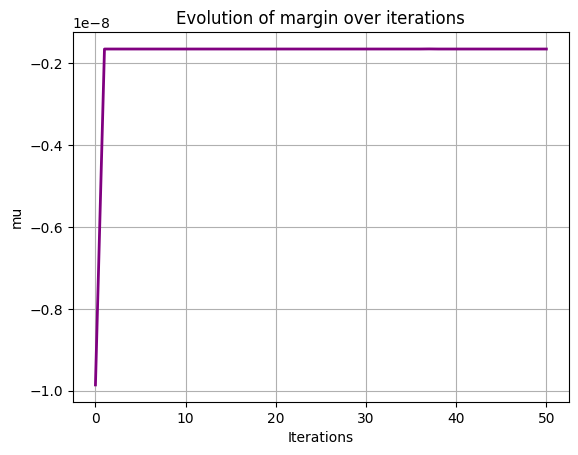

22:31:07 | INFO | machinemoo | Fit runtime: 58.99 seconds


In [11]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [12]:
results['mola']["objectives"]

array([[0.28987284, 0.39333321]])

/home/lineccsa/mestrado/moo_research/machinemoo/machinemoo/analysis/visualization.py:99: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(limits[0])
/home/lineccsa/mestrado/moo_research/machinemoo/machinemoo/analysis/visualization.py:100: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(limits[1])


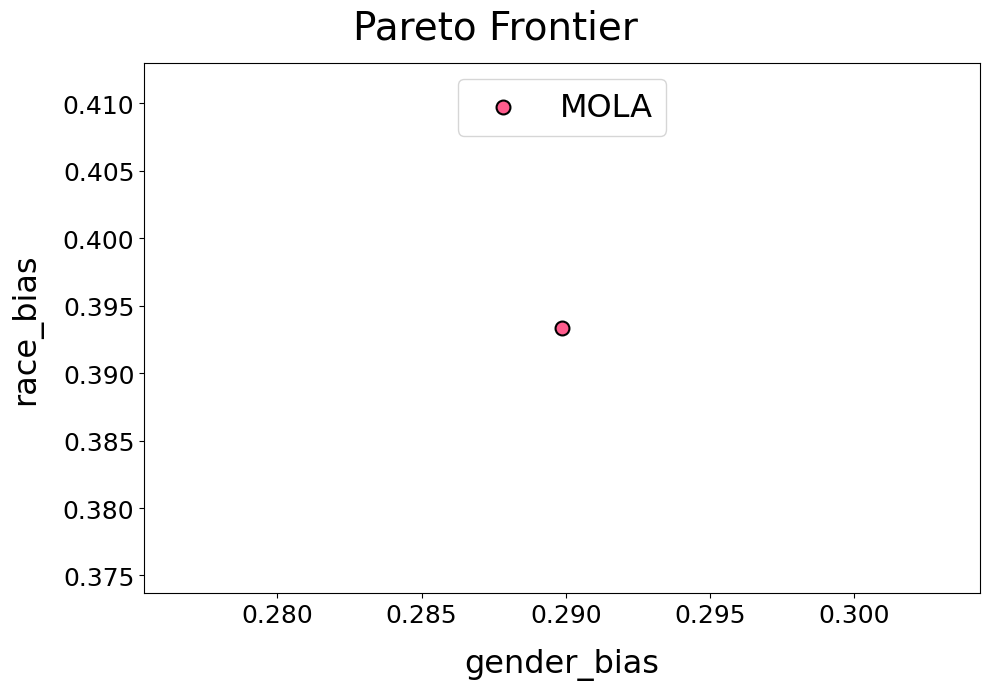

In [13]:
title="Conflict between losses in training to detect hate speech"
plot_pareto(methods={'mola': objs},
            labels=task_names, 
            # title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola_2.pdf'
            )

15:30:26 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
15:30:26 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 109.19it/s]


Epoch 1 - Average loss: 0.3548


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 110.02it/s]


Epoch 2 - Average loss: 0.3481


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 115.74it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 116.67it/s]


Epoch 2 - Average loss: 0.2392


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 112.13it/s]


Epoch 3 - Average loss: 0.2387
new solution dominated [0.58944802 0.35007568]


16:11:58 | DEBUG | machinemoo | Calculated weights: [0.45984558 0.54015442]
16:11:58 | DEBUG | machinemoo | Importance: 0.0001075000070707155
16:11:58 | DEBUG | machinemoo | Global lower bound (y*): [0.58870736 0.34959805]
16:11:58 | DEBUG | machinemoo | Iteration 301
16:11:58 | DEBUG | machinemoo | Solutions list: [array([0.58965566, 0.34959805]), array([0.58935656, 0.34968   ]), array([0.58947152, 0.3496276 ]), array([0.58883798, 0.34990197]), array([0.58872004, 0.34999783]), array([0.58870736, 0.35074633]), array([0.58905867, 0.34970954])]


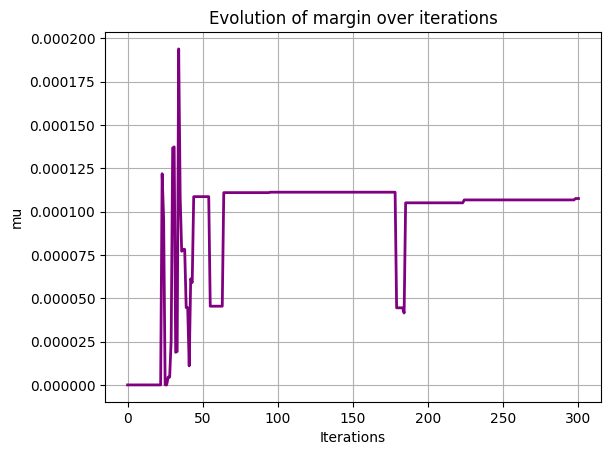

16:11:58 | INFO | machinemoo | Fit runtime: 2492.61 seconds


In [ ]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

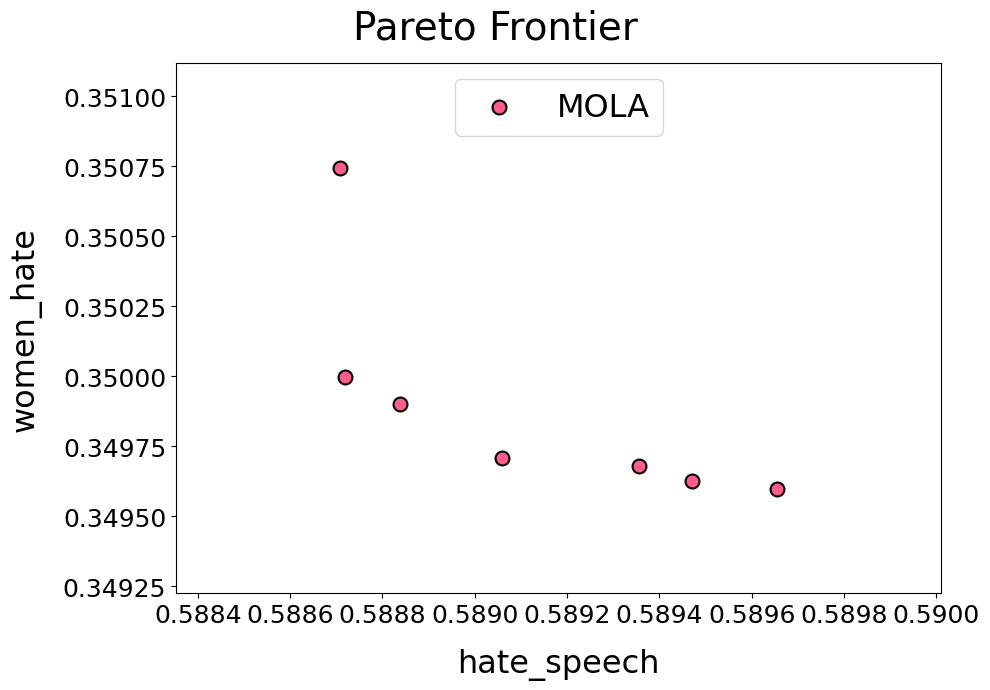

In [ ]:
title="Conflict between losses in training to detect hate speech"
plot_pareto(methods={'mola': objs},
            labels=task_names, 
            # title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola_grad_2.pdf'
            )

### Random Weight

In [ ]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

16:11:59 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
16:11:59 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 300, 'norm': False}
16:11:59 | DEBUG | machinemoo.moo.random_weights | Finding 1th individual minima
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 110.26it/s]


Epoch 1 - Average loss: 0.3457


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 115.42it/s]


Epoch 2 - Average loss: 0.3393


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 116.88it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 116.29it/s]


Epoch 2 - Average loss: 0.2085


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 117.47it/s]


Epoch 3 - Average loss: 0.2086


16:52:44 | DEBUG | machinemoo.moo.random_weights | 300th solution


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

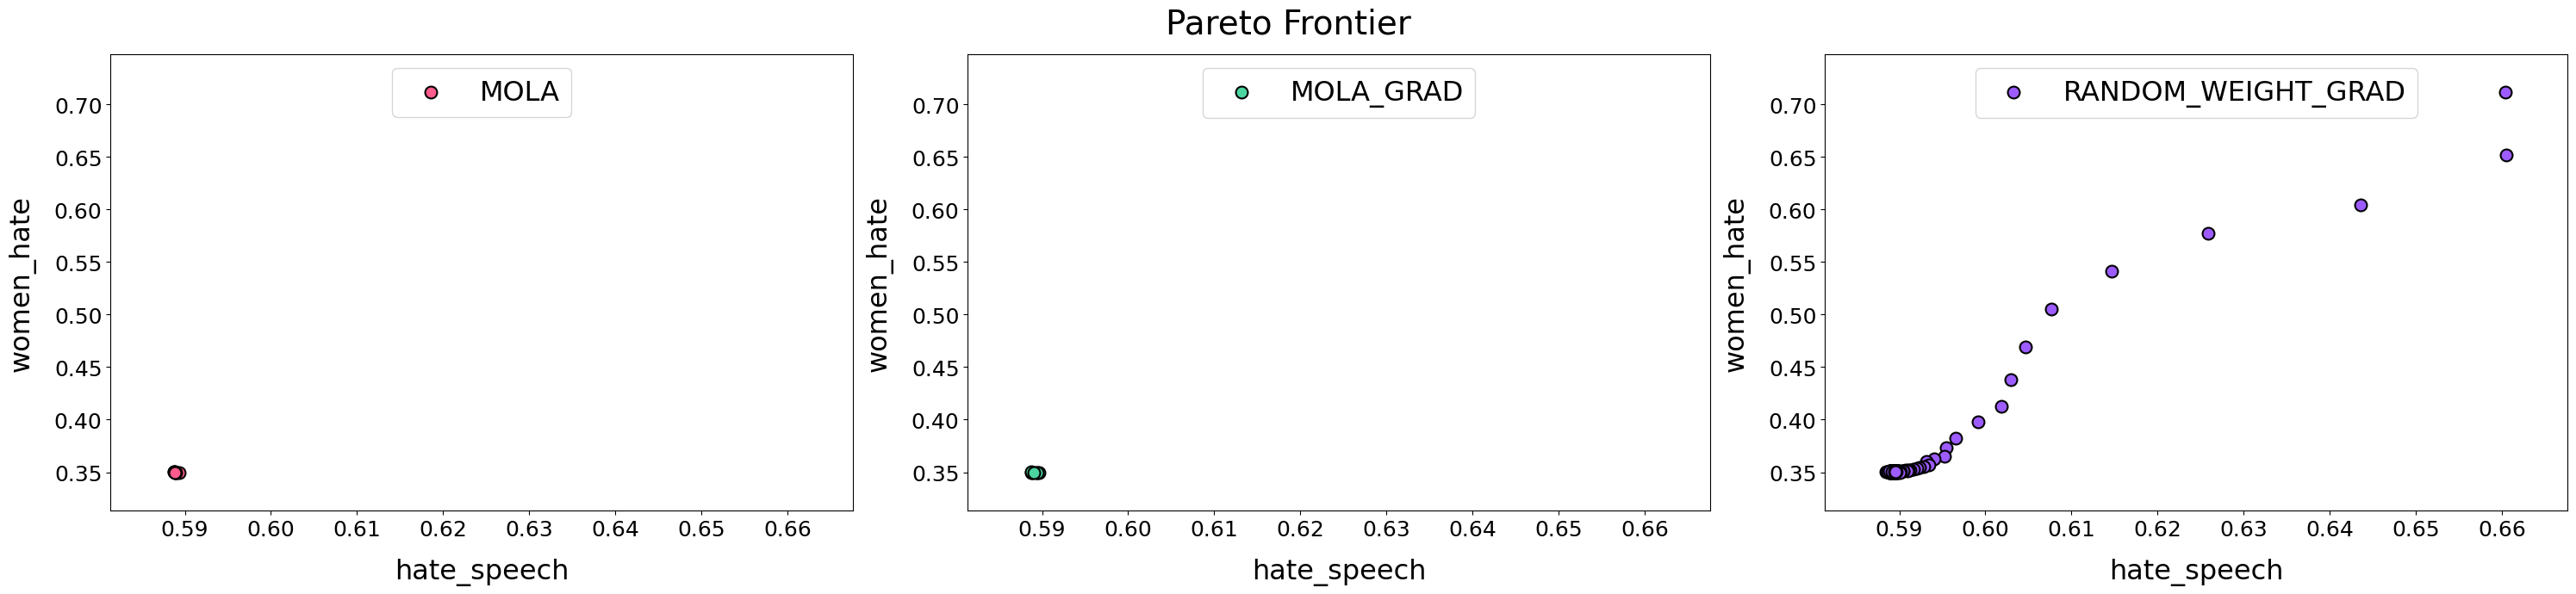

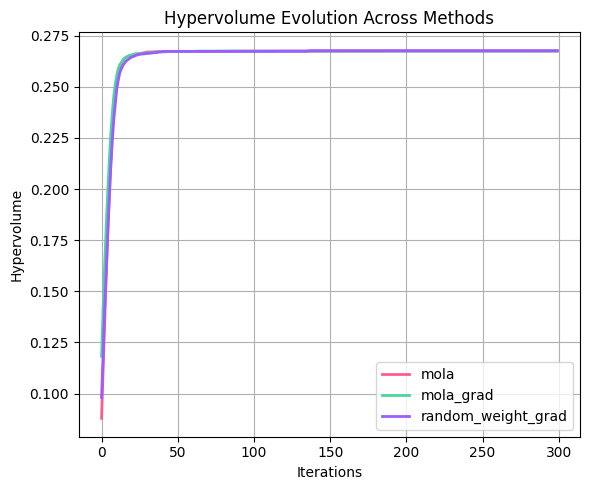

In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
plot_pareto(methods=pareto_dict,
            labels=task_names, 
            # title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_methods_2.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)

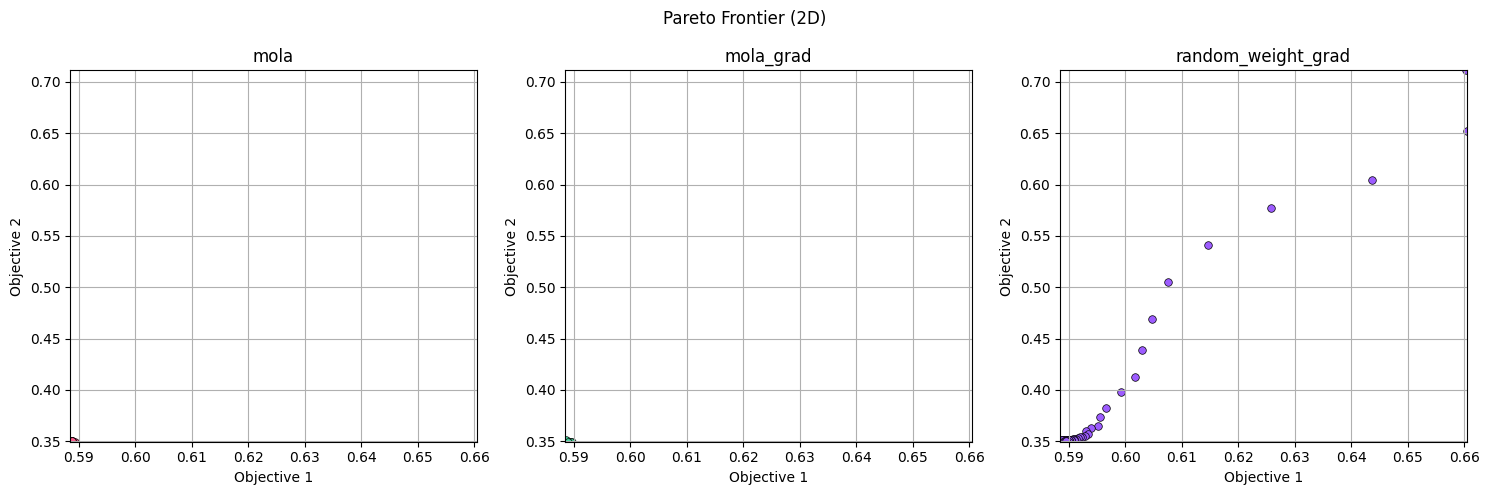

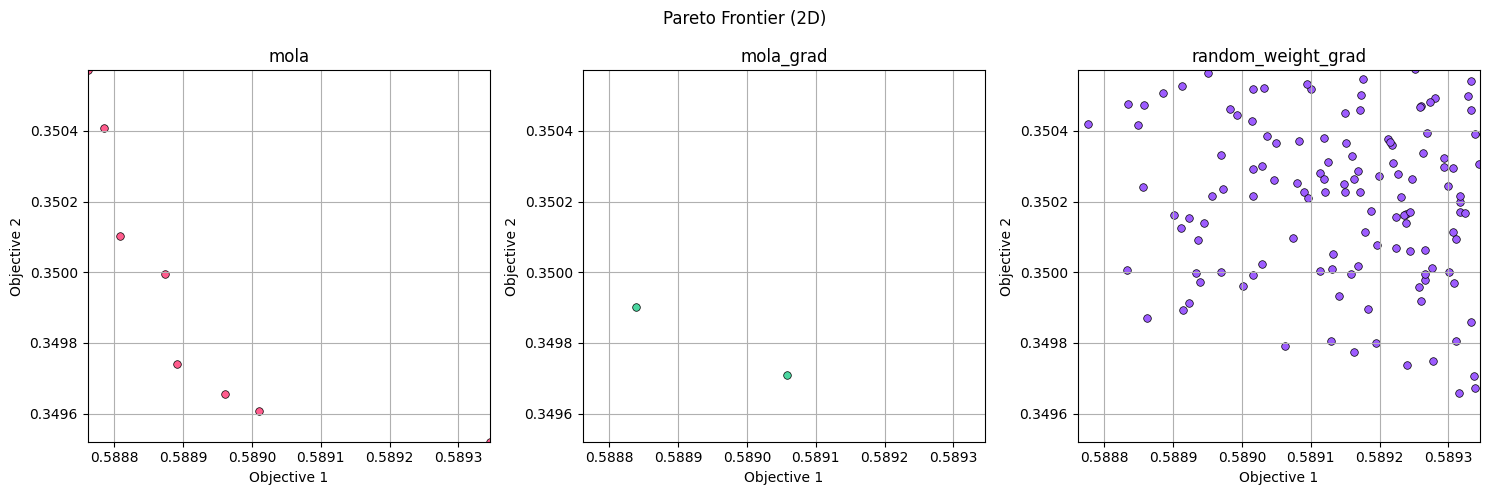

: 

In [ ]:
from machinemoo.analysis.visualization import plot_pareto_2d_set_limit
plot_pareto_2d_set_limit(pareto_dict=pareto_dict, axis_mode="global")
plot_pareto_2d_set_limit(pareto_dict=pareto_dict, axis_mode="first")